# Model Lab 2: ปรับค่าทีละตัวแล้ว F1 เปลี่ยนยังไง — Saphondanai

ต่อจาก [05_model_comparison_S.ipynb](05_model_comparison_S.ipynb) ทุกกราฟเริ่มจากค่าที่ดีที่สุดที่ Optuna หาได้ แล้ว **ปรับทีละค่า (ค่าอื่นตรึงไว้)** วัด F1 ด้วย CV 5 fold × 2 รอบบน train (ไม่แตะ test)

**อ่านกราฟยังไง**
- เส้นน้ำเงินหนา = F1 เฉลี่ย, แถบจาง = ± 1 Standard Error (SE = SD / √10 คือความไม่แน่นอนของค่าเฉลี่ย)
- เส้นส้ม = precision (ทักว่าจะลาออก ถูกกี่ %), เส้นเขียว = recall (คนที่ลาออกจริง จับได้กี่ %)
- ◆ = จุด F1 สูงสุด, เส้นตั้ง = ค่าที่ **เลือก** ตามกฎด้านล่าง

**กฎเลือกค่า: one-standard-error rule** (Hastie, Tibshirani & Friedman, *Elements of Statistical Learning* §7.10)
1. หาค่าที่ F1 สูงสุด และ SE ของมัน
2. ทุกค่าที่ F1 ≥ (สูงสุด − 1 SE) ถือว่า "ดีเท่ากันทางสถิติ"
3. เลือกค่าที่ **ง่ายที่สุด** ในกลุ่มนั้น เพราะข้อมูลมีแค่ 1,176 แถว ค่าที่ซับซ้อนกว่าแล้วชนะแบบเฉียดฉิวมักเป็นการจำ noise (overfit) ใช้กับข้อมูลใหม่แล้วแย่ลง

| ทิศ "ง่ายกว่า" | ค่า |
| :--- | :--- |
| น้อยกว่า = ง่ายกว่า | `max_depth`, `n_estimators`, `num_leaves`, `depth`, จำนวน neuron, `C` (C น้อย = regularize มาก) |
| มากกว่า = ง่ายกว่า | `n_neighbors` (k), `min_child_weight` |
| ไม่มีทิศ → เลือก F1 สูงสุด | `learning_rate`, `scale_pos_weight`, threshold |

In [1]:
import sys, json, os, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt, mlflow, numpy as np, pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

import mlflow_setup
from clean_pipeline import RAW_FILENAME, clean_data, load_raw_data
from feature_pipeline import SELECTED_FEATURES, add_features

OUT = "../docs/model_lab_S"
R = json.load(open(f"{OUT}/results.json", encoding="utf-8"))
BEST = {k: v["params"] for k, v in R["models"].items()}

df = add_features(clean_data(load_raw_data(f"../data/raw/{RAW_FILENAME}")), only=SELECTED_FEATURES)
X, y = df.drop(columns="Attrition"), df["Attrition"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)  # เหมือน 05
SPW = (ytr == 0).sum() / (ytr == 1).sum()
CV = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "muted": "#898781", "grid": "#e1e0d9", "ink": "#0b0b0b", "ink2": "#52514e"}
plt.rcParams.update({"font.family": ["Tahoma"], "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C["ink2"], "xtick.color": C["ink2"],
                     "ytick.color": C["ink2"], "axes.grid": True, "grid.color": C["grid"], "axes.axisbelow": True,
                     "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "savefig.bbox": "tight"})

## 0. ตรวจก่อน: CV F1 ใน 05 ดูดีเกินจริงแค่ไหน (nested threshold)

ใน 05 เราเลือก threshold ที่ดีที่สุดจาก OOF **แล้ววัด F1 บน OOF ชุดเดียวกัน** เหมือนให้นักเรียนออกข้อสอบเองแล้วทำเอง คะแนนจึงเข้าข้างตัวเองเล็กน้อย

**วิธีแก้ (nested):** สำหรับแต่ละ fold ให้เลือก threshold จาก **อีก 4 fold** แล้วเอาไปวัด F1 บน fold ที่ไม่ได้ใช้เลือก ใช้คะแนน OOF เดิมจาก 05 จึงไม่ต้องเทรนใหม่ ถ้า CV แบบ nested ใกล้กับ test มากขึ้น แสดงว่าช่องว่างระหว่าง CV กับ test ส่วนหนึ่งมาจาก bias นี้ ไม่ใช่โมเดลพัง

In [2]:
from sklearn.metrics import f1_score as _f1
yv0 = np.array(R["y_train"])
splits = list(CV.split(Xtr, yv0))[:5]  # รอบแรกของ CV = ชุดเดียวกับ OOF ที่เก็บไว้ใน 05

def thr_on(yt, pt):
    prec, rec, thr = precision_recall_curve(yt, pt)
    return float(thr[int(np.argmax((2 * prec * rec / np.maximum(prec + rec, 1e-12))[:-1]))])

rows, NESTED = [], {}
for name, m in R["models"].items():
    oof = np.array(m["cv"]["oof"])
    nested = [_f1(yv0[va], oof[va] >= thr_on(yv0[tr], oof[tr])) for tr, va in splits]
    NESTED[name] = {"f1_nested": float(np.mean(nested)), "f1_nested_sd": float(np.std(nested, ddof=1))}
    rows.append({"key": name, "โมเดล": R["labels"][name], "CV (threshold จากข้อมูลเดียวกัน)": m["cv"]["f1"],
                 "CV nested": NESTED[name]["f1_nested"], "test": m["test"]["f1"]})
honest = pd.DataFrame(rows).sort_values("CV nested", ascending=False)
honest["bias (CV - nested)"] = honest["CV (threshold จากข้อมูลเดียวกัน)"] - honest["CV nested"]
honest.drop(columns="key").round(3)

,โมเดล,CV (threshold จากข้อมูลเดียวกัน),CV nested,test,bias (CV - nested)
8,Ensemble (top 3),0.634,0.632,0.550,0.001
2,SVM (RBF),0.618,0.598,0.500,0.020
0,Logistic Regression,0.617,0.592,0.494,0.024
9,โมเดลเดิม (XGB Puripat),0.583,0.580,0.519,0.004
7,CatBoost,0.599,0.577,0.505,0.022
4,MLP,0.582,0.561,0.494,0.021
6,LightGBM,0.604,0.560,0.527,0.044
5,XGBoost (จูนใหม่),0.588,0.554,0.531,0.034
1,Random Forest,0.537,0.528,0.491,0.009
3,KNN,0.517,0.516,0.427,0.002


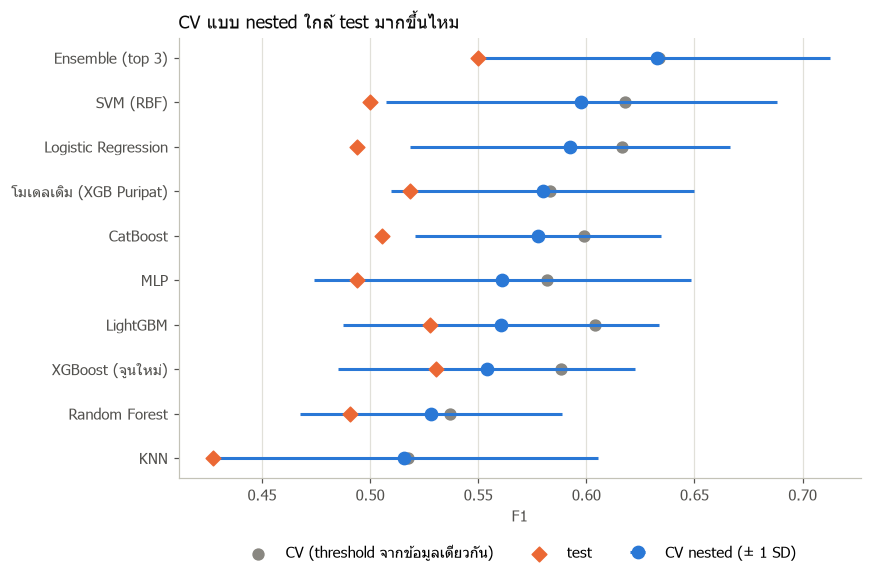

bias เฉลี่ย (CV - nested): 0.018 | ช่องว่างเฉลี่ย CV - test: 0.084 | nested - test: 0.066


In [3]:
h = honest.iloc[::-1]; yy = np.arange(len(h))
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.scatter(h["CV (threshold จากข้อมูลเดียวกัน)"], yy, color=C["muted"], s=50, label="CV (threshold จากข้อมูลเดียวกัน)")
ax.errorbar(h["CV nested"], yy, xerr=[NESTED[k]["f1_nested_sd"] for k in h["key"]], fmt="o", color=C["blue"], ms=8, lw=2,
            capsize=0, label="CV nested (± 1 SD)")
ax.scatter(h["test"], yy, marker="D", s=46, color=C["orange"], zorder=3, label="test")
ax.set_yticks(yy, h["โมเดล"]); ax.set_xlabel("F1"); ax.grid(axis="y", visible=False)
ax.set_title("CV แบบ nested ใกล้ test มากขึ้นไหม", loc="left", color=C["ink"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
fig.savefig(f"{OUT}/00_cv_honesty.png"); plt.show()
print("bias เฉลี่ย (CV - nested):", round(honest["bias (CV - nested)"].mean(), 3),
      "| ช่องว่างเฉลี่ย CV - test:", round((honest["CV (threshold จากข้อมูลเดียวกัน)"] - honest["test"]).mean(), 3),
      "| nested - test:", round((honest["CV nested"] - honest["test"]).mean(), 3))

In [4]:
# ตัวสร้างโมเดล: ค่าตั้งต้น = ค่าที่ดีที่สุดจาก 05 แล้ว override ทีละค่า
BUILD = {
    "LogReg": lambda p: make_pipeline(StandardScaler(), LogisticRegression(C=p["C"], class_weight="balanced", max_iter=3000)),
    "RandomForest": lambda p: RandomForestClassifier(**p, class_weight="balanced", n_jobs=-1, random_state=42),
    "SVM": lambda p: make_pipeline(StandardScaler(), SVC(**p, kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
    "KNN": lambda p: make_pipeline(StandardScaler(), KNeighborsClassifier(**p)),
    "MLP": lambda p: make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(p["units"],) * p["layers"], alpha=p["alpha"],
                                                                learning_rate_init=p["lr"], max_iter=1000, early_stopping=True, random_state=42)),
    "XGBoost": lambda p: XGBClassifier(**{"scale_pos_weight": SPW, **p}, random_state=42, n_jobs=4),
    "LightGBM": lambda p: LGBMClassifier(**p, class_weight="balanced", subsample_freq=1, random_state=42, n_jobs=4, verbose=-1),
    "CatBoost": lambda p: CatBoostClassifier(**p, auto_class_weights="Balanced", random_seed=42, thread_count=4, verbose=0, allow_writing_files=False),
}

def cv_scores(model):
    """F1 ที่ threshold ดีที่สุด (จาก OOF) + precision/recall ที่ threshold นั้น + F1 ที่ 0.5 เฉลี่ย 10 fold"""
    yv = ytr.to_numpy()
    reps, folds, p = [], [], np.zeros(len(yv))
    for i, (tr, va) in enumerate(CV.split(Xtr, yv)):
        m = clone(model).fit(Xtr.iloc[tr], yv[tr])
        p[va] = m.predict_proba(Xtr.iloc[va])[:, 1]
        folds.append((len(reps), va))
        if (i + 1) % 5 == 0:
            reps.append(p.copy()); p = np.zeros(len(yv))
    prec, rec, thr = precision_recall_curve(np.tile(yv, len(reps)), np.concatenate(reps))
    t = float(thr[int(np.argmax((2 * prec * rec / np.maximum(prec + rec, 1e-12))[:-1]))])
    f1 = [f1_score(yv[va], reps[r][va] >= t) for r, va in folds]
    return {"f1": np.mean(f1), "se": np.std(f1, ddof=1) / np.sqrt(len(f1)), "threshold": t,
            "precision": np.mean([precision_score(yv[va], reps[r][va] >= t, zero_division=0) for r, va in folds]),
            "recall": np.mean([recall_score(yv[va], reps[r][va] >= t) for r, va in folds]),
            "f1_at_05": np.mean([f1_score(yv[va], reps[r][va] >= 0.5) for r, va in folds])}

def pick(values, rows, simpler):
    """กฎ 1-SE: คืน (ค่าที่ F1 สูงสุด, ค่าที่เลือก)"""
    f1 = np.array([r["f1"] for r in rows]); b = int(np.argmax(f1))
    if simpler is None:
        return values[b], values[b]
    ok = [v for v, f in zip(values, f1) if f >= f1[b] - rows[b]["se"]]
    return values[b], (min(ok) if simpler == "lower" else max(ok))

In [5]:
LABEL = R["labels"]
def plot_sweep(s, show_f1_05=False):
    v = np.array(s["values"], dtype=float); f1 = np.array(s["f1"]); se = np.array(s["se"])
    fig, ax = plt.subplots(figsize=(7, 3.9))
    ax.fill_between(v, f1 - se, f1 + se, color=C["blue"], alpha=0.15, lw=0)
    ax.plot(v, f1, color=C["blue"], lw=2.5, marker="o", ms=4, label="F1 (threshold ดีที่สุด)")
    ax.plot(v, s["precision"], color=C["orange"], lw=1.3, label="precision")
    ax.plot(v, s["recall"], color=C["aqua"], lw=1.3, label="recall")
    if show_f1_05:
        ax.plot(v, s["f1_at_05"], color=C["muted"], lw=1.5, marker="o", ms=3, label="F1 ที่ threshold 0.5")
    i = s["values"].index(s["best"])
    ax.scatter([s["best"]], [f1[i]], marker="D", s=60, color=C["blue"], zorder=4, edgecolor="white", linewidth=1.5)
    ax.axvline(s["chosen"], color=C["ink2"], lw=1)
    ax.annotate(f"เลือก {s['chosen']:g}", (s["chosen"], ax.get_ylim()[1]), xytext=(4, -12), textcoords="offset points", color=C["ink2"])
    if s["scale"] == "log":
        ax.set_xscale("log")
    ax.set_xlabel(s["param"]); ax.set_ylabel("คะแนน (CV)")
    ax.set_title(f"{LABEL[s['model']]}: ปรับ {s['param']}", loc="left", color=C["ink"])
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False, fontsize=9)
    fig.savefig(f"{OUT}/sweep_{s['model']}_{s['param']}.png"); plt.show()

SWEEPS = []
def run_sweep(model, param, values, simpler, scale="linear", show_f1_05=False):
    rows = [cv_scores(BUILD[model]({**BEST[model], param: val})) for val in values]
    best, chosen = pick(values, rows, simpler)
    s = {"model": model, "param": param, "values": list(values), "simpler": simpler, "scale": scale, "best": best, "chosen": chosen,
         **{k: [float(r[k]) for r in rows] for k in ("f1", "se", "precision", "recall", "f1_at_05", "threshold")}}
    SWEEPS.append(s); plot_sweep(s, show_f1_05)
    i, j = values.index(best), values.index(chosen)
    print(f"F1 สูงสุด {s['f1'][i]:.3f} ที่ {param}={best:g} | เลือก {param}={chosen:g} (F1 {s['f1'][j]:.3f}, "
          f"ห่าง {s['f1'][i] - s['f1'][j]:.3f} ≤ 1 SE = {s['se'][i]:.3f}) | ค่าจาก Optuna = {BEST[model].get(param, round(SPW, 2) if param == 'scale_pos_weight' else None)}")
    return s

## 1. XGBoost

### 1.1 `max_depth` — ความลึกของต้นไม้ (1–10)
ต้นไม้ลึก = จับความสัมพันธ์ซับซ้อนหลายฟีเจอร์พร้อมกันได้ แต่ก็จำ noise ได้ง่าย ต้นตื้น = เรียนรู้แบบหยาบแต่ทนกว่า

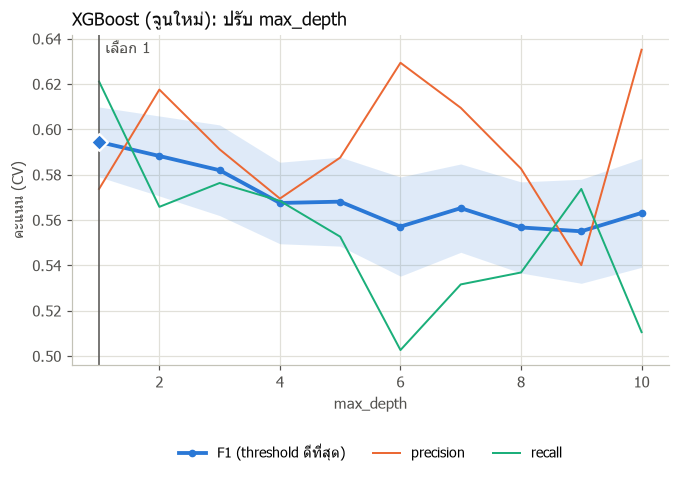

F1 สูงสุด 0.594 ที่ max_depth=1 | เลือก max_depth=1 (F1 0.594, ห่าง 0.000 ≤ 1 SE = 0.015) | ค่าจาก Optuna = 2


In [6]:
run_sweep("XGBoost", "max_depth", list(range(1, 11)), "lower");

### 1.2 `n_estimators` — จำนวนต้นไม้ (50–1000)
boosting เพิ่มต้นไม้ทีละต้นเพื่อแก้จุดที่ต้นก่อนพลาด น้อยไป = ยังเรียนไม่พอ (underfit) มากไป = เริ่มไล่แก้ noise

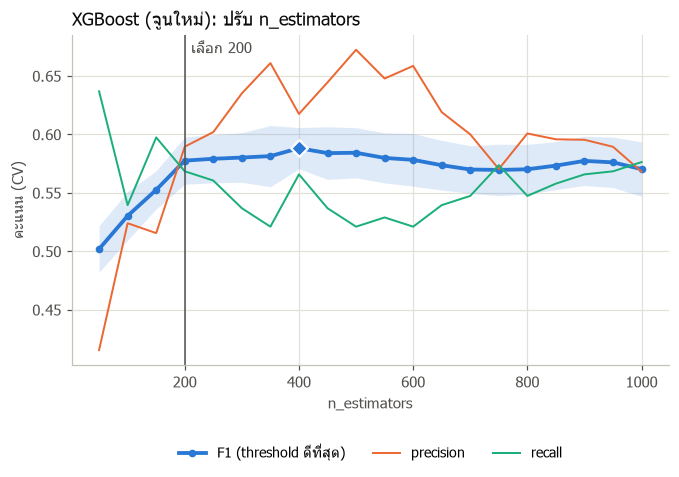

F1 สูงสุด 0.588 ที่ n_estimators=400 | เลือก n_estimators=200 (F1 0.578, ห่าง 0.011 ≤ 1 SE = 0.018) | ค่าจาก Optuna = 400


In [7]:
run_sweep("XGBoost", "n_estimators", list(range(50, 1001, 50)), "lower");

### 1.3 `learning_rate` — ก้าวการเรียนรู้ (0.005–0.3)
แต่ละต้นแก้ความผิดพลาดแรงแค่ไหน ค่าน้อยต้องใช้ต้นไม้มากขึ้นถึงจะเรียนทัน ค่ามากเรียนเร็วแต่แกว่ง ค่านี้คู่กับ `n_estimators` เสมอ

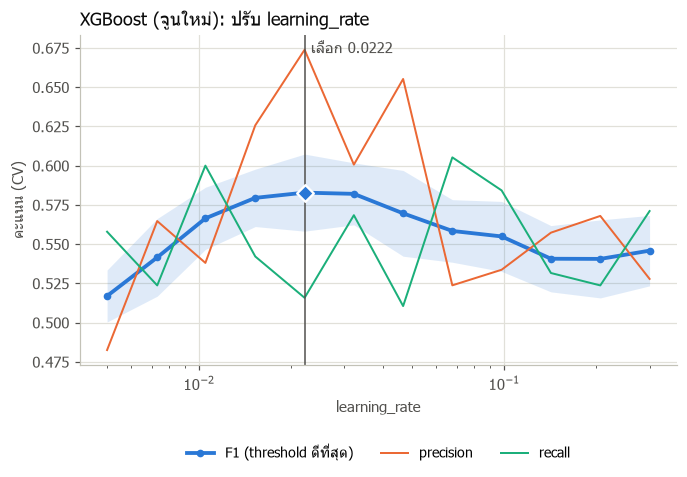

F1 สูงสุด 0.583 ที่ learning_rate=0.0222 | เลือก learning_rate=0.0222 (F1 0.583, ห่าง 0.000 ≤ 1 SE = 0.025) | ค่าจาก Optuna = 0.02548200937891461


In [8]:
run_sweep("XGBoost", "learning_rate", [float(round(v, 4)) for v in np.geomspace(0.005, 0.3, 12)], None, "log");

### 1.4 `min_child_weight` — ขนาดใบขั้นต่ำ (1–20)
ใบของต้นไม้ต้องมีข้อมูล "หนัก" อย่างน้อยเท่านี้ถึงจะแตกกิ่งได้ ค่ามาก = ห้ามสร้างกฎจากคนไม่กี่คน (กัน overfit)

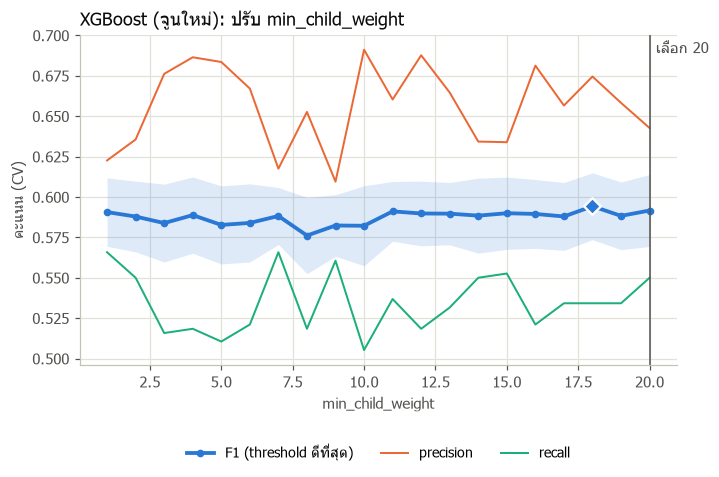

F1 สูงสุด 0.594 ที่ min_child_weight=18 | เลือก min_child_weight=20 (F1 0.592, ห่าง 0.003 ≤ 1 SE = 0.021) | ค่าจาก Optuna = 7


In [9]:
run_sweep("XGBoost", "min_child_weight", list(range(1, 21)), "higher");

### 1.5 `scale_pos_weight` — น้ำหนักคนลาออก (1–10)
1 = ไม่ถ่วง, 5.19 = ถ่วงให้สองกลุ่มหนักเท่ากัน กราฟนี้วาด **F1 ที่ threshold 0.5 (เทา)** เทียบ **F1 ที่ threshold จูนแล้ว (น้ำเงิน)** เพื่อตอบคำถามว่า "ถ้าจูน threshold แล้ว ยังต้องถ่วงน้ำหนักอีกไหม"

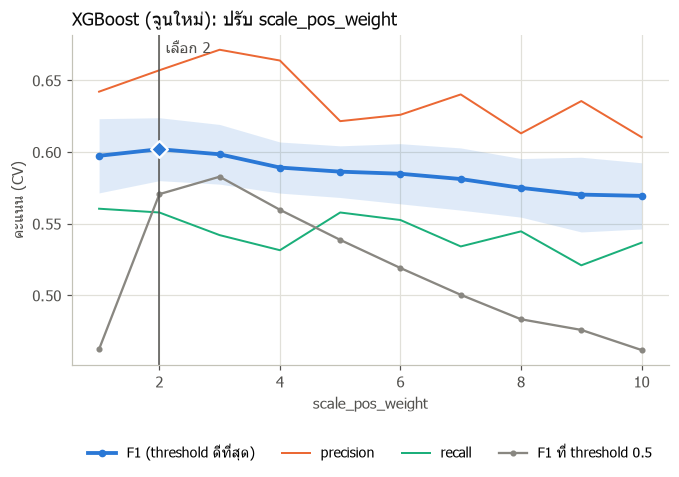

F1 สูงสุด 0.602 ที่ scale_pos_weight=2 | เลือก scale_pos_weight=2 (F1 0.602, ห่าง 0.000 ≤ 1 SE = 0.022) | ค่าจาก Optuna = 5.19


In [10]:
run_sweep("XGBoost", "scale_pos_weight", list(range(1, 11)), None, show_f1_05=True);

## 2. threshold ของโมเดลที่ดีที่สุด (0.05–0.95)

ไม่ต้องเทรนใหม่ ใช้คะแนน out-of-fold ของ train จาก 05 แล้วลองตัดที่ threshold ต่าง ๆ
threshold ต่ำ = ทักว่า "จะลาออก" ง่าย (recall สูง precision ต่ำ) / threshold สูง = ทักเฉพาะคนที่มั่นใจ (precision สูง recall ต่ำ) F1 คือจุดสมดุลของสองค่านี้

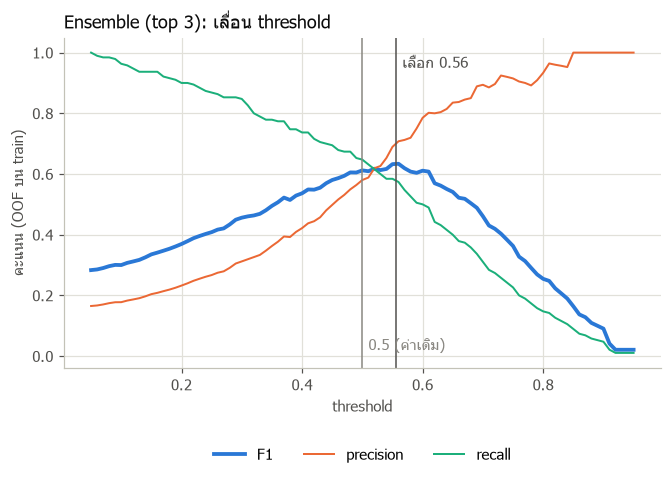

Ensemble (top 3): F1 ที่ 0.5 = 0.612 | ที่ 0.56 = 0.634 (OOF รอบแรก)


In [11]:
cands = [k for k in R["models"] if k != "Baseline"]
TOP = max(cands, key=lambda k: R["models"][k]["cv"]["f1"])
oof, yv = np.array(R["models"][TOP]["cv"]["oof"]), np.array(R["y_train"])
ths = [round(t, 2) for t in np.arange(0.05, 0.951, 0.01)]
curve = {"model": TOP, "thresholds": ths, "f1": [], "precision": [], "recall": []}
for t in ths:
    pred = oof >= t
    curve["f1"].append(f1_score(yv, pred)); curve["precision"].append(precision_score(yv, pred, zero_division=0)); curve["recall"].append(recall_score(yv, pred))
curve["chosen"] = R["models"][TOP]["cv"]["threshold"]
fig, ax = plt.subplots(figsize=(7, 3.9))
ax.plot(ths, curve["f1"], color=C["blue"], lw=2.5, label="F1")
ax.plot(ths, curve["precision"], color=C["orange"], lw=1.3, label="precision")
ax.plot(ths, curve["recall"], color=C["aqua"], lw=1.3, label="recall")
ax.axvline(0.5, color=C["muted"], lw=1); ax.annotate("0.5 (ค่าเดิม)", (0.5, 0.02), xytext=(4, 0), textcoords="offset points", color=C["muted"])
ax.axvline(curve["chosen"], color=C["ink2"], lw=1); ax.annotate(f"เลือก {curve['chosen']:.2f}", (curve["chosen"], 0.95), xytext=(4, 0), textcoords="offset points", color=C["ink2"])
ax.set_xlabel("threshold"); ax.set_ylabel("คะแนน (OOF บน train)"); ax.set_title(f"{LABEL[TOP]}: เลื่อน threshold", loc="left", color=C["ink"])
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)
fig.savefig(f"{OUT}/threshold_{TOP}.png"); plt.show()
i = ths.index(0.5); print(f"{LABEL[TOP]}: F1 ที่ 0.5 = {curve['f1'][i]:.3f} | ที่ {curve['chosen']:.2f} = {max(curve['f1']):.3f} (OOF รอบแรก)")

## 3. ค่าหลักของโมเดลอื่น

### 3.1 KNN: `n_neighbors` (k = 1–50)
k น้อย = ตัดสินจากเพื่อนบ้านไม่กี่คน ไวต่อ noise (overfit), k มาก = เฉลี่ยจากคนจำนวนมาก เรียบขึ้นแต่เริ่มมองไม่เห็นกลุ่มย่อย

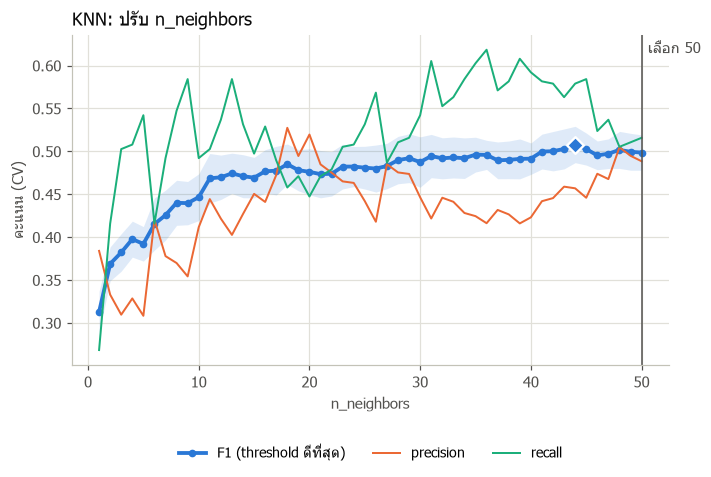

F1 สูงสุด 0.508 ที่ n_neighbors=44 | เลือก n_neighbors=50 (F1 0.499, ห่าง 0.009 ≤ 1 SE = 0.021) | ค่าจาก Optuna = 58


In [12]:
run_sweep("KNN", "n_neighbors", list(range(1, 51)), "higher");

### 3.2 Random Forest: `n_estimators` (10–500) และ `max_depth` (1–20)
Random Forest เพิ่มต้นไม้แล้ว **ไม่ overfit เพิ่ม** (แค่โหวตนิ่งขึ้น) จึงคาดว่าเส้นจะขึ้นแล้วแบน ส่วนความลึกคุมความซับซ้อนจริง

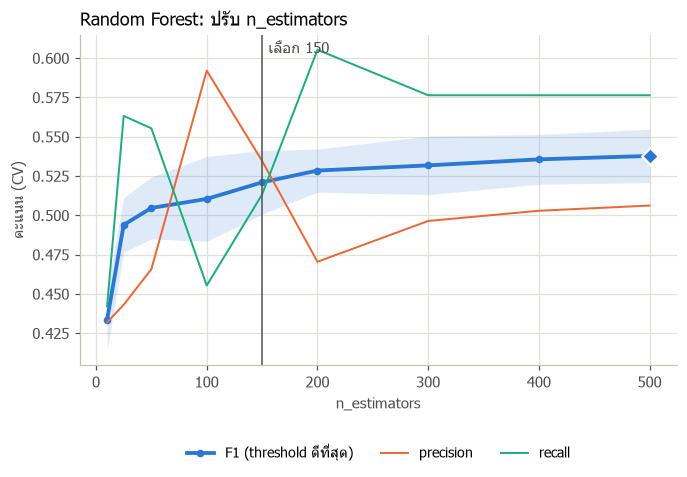

F1 สูงสุด 0.538 ที่ n_estimators=500 | เลือก n_estimators=150 (F1 0.521, ห่าง 0.017 ≤ 1 SE = 0.017) | ค่าจาก Optuna = 450


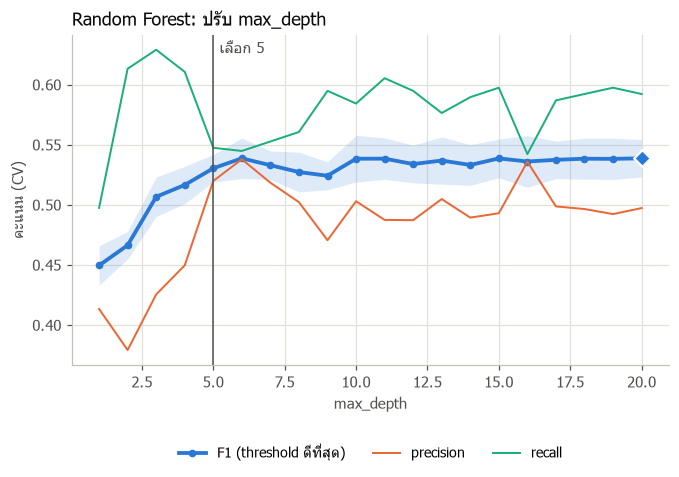

F1 สูงสุด 0.539 ที่ max_depth=20 | เลือก max_depth=5 (F1 0.530, ห่าง 0.008 ≤ 1 SE = 0.016) | ค่าจาก Optuna = 13


In [13]:
run_sweep("RandomForest", "n_estimators", [10, 25, 50, 100, 150, 200, 300, 400, 500], "lower")
run_sweep("RandomForest", "max_depth", list(range(1, 21)), "lower");

### 3.3 SVM และ Logistic Regression: `C` (0.001–100)
`C` คือ "ยอมให้โมเดลโค้งตามข้อมูลแค่ไหน" C น้อย = บังคับให้เรียบ (regularize มาก), C มาก = ไล่ตามข้อมูลทุกจุด

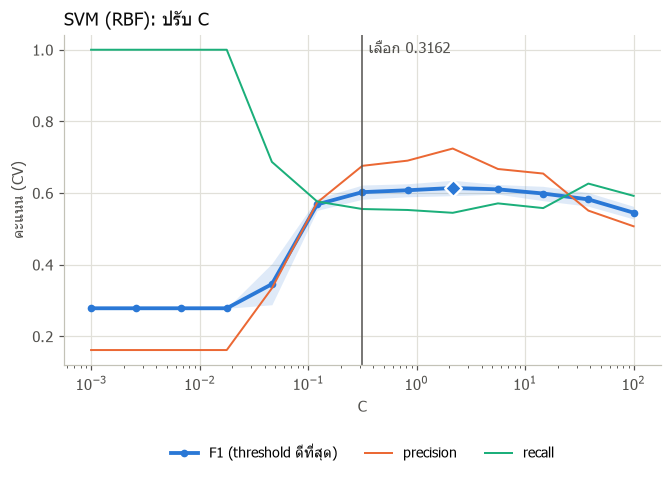

F1 สูงสุด 0.614 ที่ C=2.1544 | เลือก C=0.3162 (F1 0.602, ห่าง 0.012 ≤ 1 SE = 0.022) | ค่าจาก Optuna = 3.819908029738812


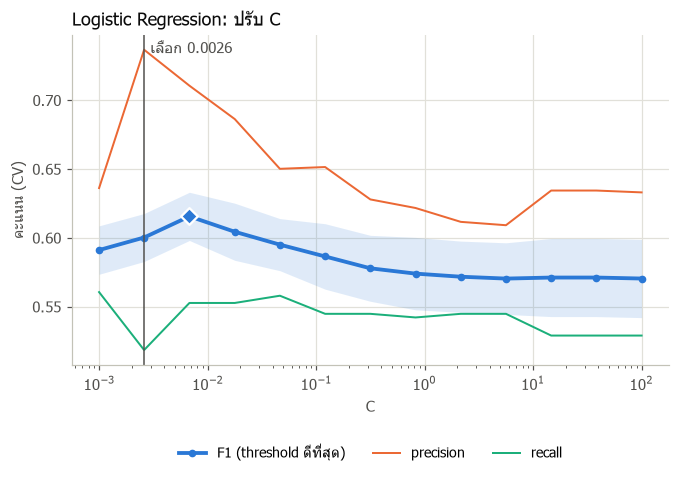

F1 สูงสุด 0.616 ที่ C=0.0068 | เลือก C=0.0026 (F1 0.600, ห่าง 0.015 ≤ 1 SE = 0.018) | ค่าจาก Optuna = 0.00753079376539473


In [14]:
run_sweep("SVM", "C", [float(round(v, 4)) for v in np.geomspace(0.001, 100, 13)], "lower", "log")
run_sweep("LogReg", "C", [float(round(v, 4)) for v in np.geomspace(0.001, 100, 13)], "lower", "log");

### 3.4 MLP: จำนวน neuron ต่อชั้น (4–256)
neuron มาก = ความจุในการจำสูง ข้อมูล 1,176 แถวอาจไม่พอให้ใช้ความจุนั้นได้โดยไม่ overfit

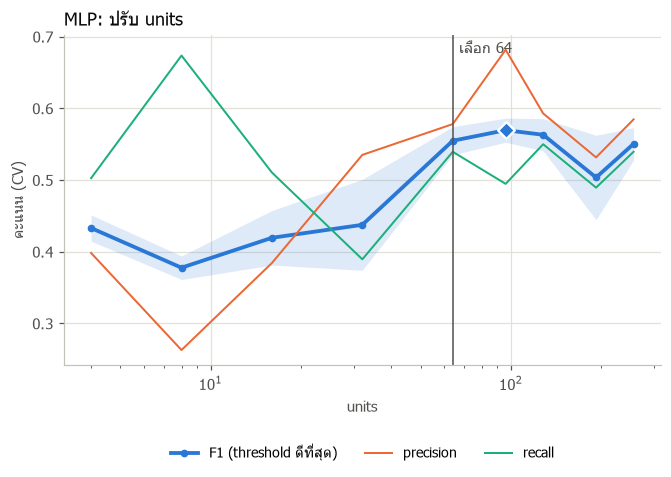

F1 สูงสุด 0.570 ที่ units=96 | เลือก units=64 (F1 0.555, ห่าง 0.015 ≤ 1 SE = 0.017) | ค่าจาก Optuna = 104


In [15]:
run_sweep("MLP", "units", [4, 8, 16, 32, 64, 96, 128, 192, 256], "lower", "log");

### 3.5 LightGBM: `num_leaves` (2–64) และ CatBoost: `depth` (1–10)
ทั้งสองค่าคุมขนาดต้นไม้แต่ละต้น เหมือน `max_depth` ของ XGBoost (LightGBM โตทีละใบ จึงคุมด้วยจำนวนใบแทนความลึก)

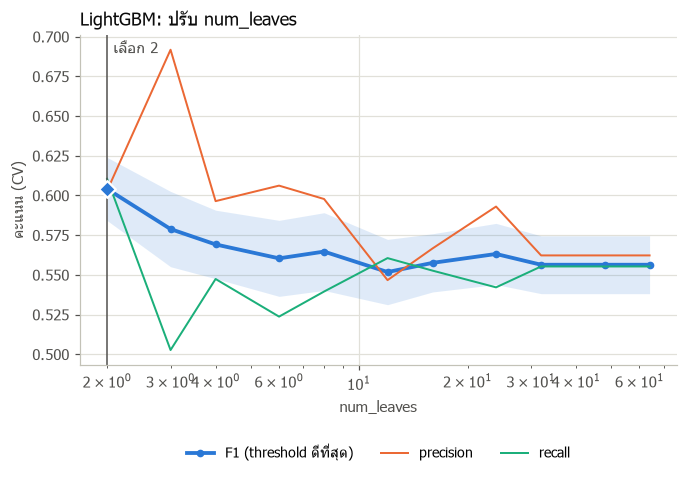

F1 สูงสุด 0.604 ที่ num_leaves=2 | เลือก num_leaves=2 (F1 0.604, ห่าง 0.000 ≤ 1 SE = 0.020) | ค่าจาก Optuna = 2


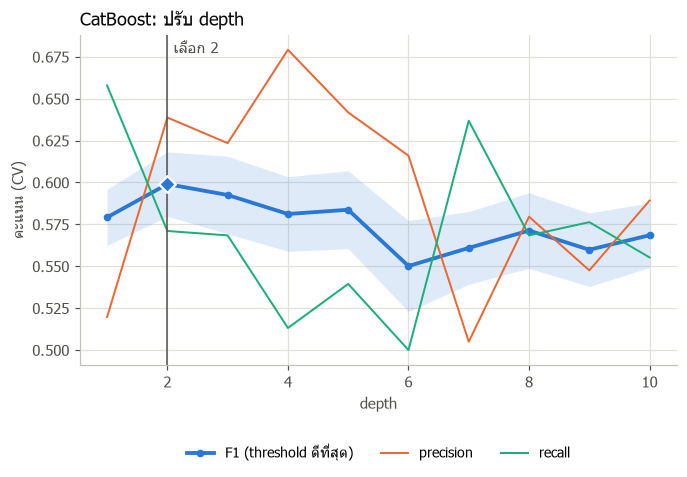

F1 สูงสุด 0.599 ที่ depth=2 | เลือก depth=2 (F1 0.599, ห่าง 0.000 ≤ 1 SE = 0.019) | ค่าจาก Optuna = 2


In [16]:
run_sweep("LightGBM", "num_leaves", [2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64], "lower", "log")
run_sweep("CatBoost", "depth", list(range(1, 11)), "lower");

## 4. สรุปทุก sweep

In [17]:
summary = pd.DataFrame([{"โมเดล": LABEL[s["model"]], "ค่า": s["param"], "Optuna เลือก": BEST[s["model"]].get(s["param"], round(SPW, 2) if s["param"] == "scale_pos_weight" else None),
                         "F1 สูงสุดที่": s["best"], "F1 สูงสุด": max(s["f1"]), "เลือกตาม 1-SE": s["chosen"],
                         "F1 ที่เลือก": s["f1"][s["values"].index(s["chosen"])]} for s in SWEEPS])
summary.round(3)

,โมเดล,ค่า,Optuna เลือก,F1 สูงสุดที่,F1 สูงสุด,เลือกตาม 1-SE,F1 ที่เลือก
0,XGBoost (จูนใหม่),max_depth,2.000,1.000,0.594,1.000,0.594
1,XGBoost (จูนใหม่),n_estimators,400.000,400.000,0.588,200.000,0.578
2,XGBoost (จูนใหม่),learning_rate,0.025,0.022,0.583,0.022,0.583
3,XGBoost (จูนใหม่),min_child_weight,7.000,18.000,0.594,20.000,0.592
4,XGBoost (จูนใหม่),scale_pos_weight,5.190,2.000,0.602,2.000,0.602
5,KNN,n_neighbors,58.000,44.000,0.508,50.000,0.499
6,Random Forest,n_estimators,450.000,500.000,0.538,150.000,0.521
7,Random Forest,max_depth,13.000,20.000,0.539,5.000,0.530
8,SVM (RBF),C,3.820,2.154,0.614,0.316,0.602
9,Logistic Regression,C,0.008,0.007,0.616,0.003,0.600


In [18]:
# เขียนแยกไฟล์ ไม่แตะ results.json ของ 05 (รัน 05 ใหม่แล้วผลของ 06 จะไม่หาย)
json.dump({"sweeps": SWEEPS, "threshold_curve": curve, "nested": NESTED},
          open(f"{OUT}/sweeps.json", "w", encoding="utf-8"), ensure_ascii=False, default=str)

# แนบกราฟ sweep เข้า MLflow run ของโมเดลนั้น (run จาก 05)
try:
    mlflow_setup.setup()
    runs = mlflow.search_runs(experiment_names=["attrition-model-lab-S"], order_by=["start_time DESC"])
    for model in {s["model"] for s in SWEEPS} | {TOP}:
        run = runs[runs["tags.model"] == model].head(1)
        if run.empty:
            continue
        with mlflow.start_run(run_id=run["run_id"].iloc[0]):
            for f in os.listdir(OUT):
                if f.endswith(".png") and (f.startswith(f"sweep_{model}_") or f == f"threshold_{model}.png"):
                    mlflow.log_artifact(f"{OUT}/{f}", artifact_path="sweeps")
    print("แนบกราฟเข้า MLflow แล้ว")
except Exception as e:
    print("⚠ แนบกราฟเข้า MLflow ไม่สำเร็จ (กราฟยังอยู่ใน docs/model_lab_S):", e)

🏃 View run lab-LightGBM at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/4e0c8acd9581439aa0012f505047b997
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-MLP at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/f5a20e05e9884d77bdb9a43d4762a440
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-CatBoost at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/e49f602682b64706a319396fc3f02d2d
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-LogReg at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/3778a3b644c542a4a6f25df60019b5fe
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-RandomForest at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/c94ef8ad82e54b21baeac018d22c2c25
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-SVM at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/816333134810410f9e44fbd312239048
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-Ensemble at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/da12cb8106ae4d038f822699df702612
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-KNN at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/ff6ae67c198b403f8838bfdfea7251c6
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


🏃 View run lab-XGBoost at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2/runs/f6864e4e18b64f95957234d8478537e5
🧪 View experiment at: https://dagshub.com/InkSpuDek66/employee-attrition-predictor.mlflow/#/experiments/2


แนบกราฟเข้า MLflow แล้ว


## 5. สรุป

1. **threshold สำคัญกว่า class weight:** ถ้าตรึง threshold ที่ 0.5 ค่า `scale_pos_weight` ทำให้ F1 แกว่งตั้งแต่ 0.46 ถึง 0.58 แต่เมื่อจูน threshold แล้ว F1 อยู่ที่ 0.57–0.60 ทุกค่า เพราะ weight แค่เลื่อนคะแนนทั้งชุดขึ้นลง ซึ่ง threshold ชดเชยให้ได้ ข้อสรุปเชิงปฏิบัติคือจูน threshold ทุกครั้ง แทนการไล่จูน weight
2. **ต้นไม้ตื้นพอ:** XGBoost ได้ F1 สูงสุดที่ `max_depth` = 1, LightGBM `num_leaves` = 2, CatBoost `depth` = 2 ต้นไม้ที่ลึกกว่านี้เริ่มจำ noise ในข้อมูล 1,176 แถว
3. **กฎ 1-SE เลือกค่าที่ง่ายกว่าได้หลายจุดโดยไม่เสีย F1 อย่างมีนัยสำคัญ:**
   - XGBoost `n_estimators` 400 → 200
   - RF `max_depth` 20 → 5 และ `n_estimators` 500 → 150
   - SVM `C` 2.15 → 0.32 และ LogReg `C` 0.0068 → 0.0026
   - MLP units 96 → 64

   ค่าที่ง่ายกว่ามักทนกว่าเมื่อเจอข้อมูลใหม่ (เช่น ข้อมูลบริษัทไทยตอน recalibrate)
4. **Random Forest เพิ่มต้นไม้แล้วไม่ overfit** เส้นขึ้นแล้วแบนตามทฤษฎี จึงเลือกจำนวนต้นน้อยที่สุดที่พอได้
5. **KNN:** F1 ดีขึ้นเรื่อย ๆ จนถึงขอบช่วงที่ลอง (k = 50) และ Optuna เลือก 58 แต่ยังอ่อนกว่าโมเดลอื่นมาก จึงไม่ขยายช่วงต่อ
6. **ข้อจำกัด:** ปรับทีละค่าโดยตรึงค่าอื่นไว้ จึงไม่เห็นผลร่วม (เช่น `learning_rate` คู่กับ `n_estimators`) ส่วนนั้น Optuna ใน 05 ค้นร่วมกันอยู่แล้ว

---
**ที่มาของข้อมูล:** IBM HR Analytics Employee Attrition & Performance ([Kaggle](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)) ข้อมูลสมมติที่สร้างโดย IBM data scientists ใช้ภายใต้ [ODbL v1.0](https://opendatacommons.org/licenses/odbl/1-0/) / [DbCL v1.0](https://opendatacommons.org/licenses/dbcl/1-0/) ดูรายละเอียดที่ [docs/dataset.md](../docs/dataset.md)